# Experiment — Improving RAG on real papers (Root Apical Meristem)

A real corpus (10 plant-biology PDFs → Markdown) exposes problems toy corpora
hide. We test two fixes and **measure** them:

1. **Strip references** — bibliography fragments were being retrieved as if they
   were content.
2. **Stronger embedder** — MiniLM (384d, 256-token cap) → **bge-small**
   (384d, retrieval-tuned, 512-token window — no truncation).

**Metric:** `ref-noise` = fraction of retrieved chunks that are actually citation
fragments. Unlike raw cosine distance (whose scale differs per model), this is
comparable across all configs.

**Before running:** `./tunnel.sh` (Postgres). Embedding runs locally on CPU here.


In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np

# Walk up from the current folder until we find the one containing `shared/` —
# that's the labs root. Add it (and this lab's folder) to the import path so
# `import ram_rag` and `from shared... import` work no matter where Jupyter
# was launched from.
current_dir = Path.cwd()
labs_folder = next(d for d in [current_dir, *current_dir.parents] if (d / "shared").exists())
print("labs root:", labs_folder)
for import_dir in (str(labs_folder), str(labs_folder / "ingestion")):
    if import_dir not in sys.path:
        sys.path.insert(0, import_dir)

import ram_rag
print("questions:", len(ram_rag.load_questions()), "| papers:", len(ram_rag.load_markdown()))

labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs
questions: 20 | papers: 10


## The problem, made concrete
`ref_density()` counts citation markers (years, `[36]`, `et al`, DOIs) per 100
words. Bibliography chunks score sky-high; real prose scores low. Here's the
worst offender in the raw corpus — exactly the kind of chunk that was polluting
retrieval.

In [2]:
raw_chunks = ram_rag.load_chunks(True)
worst_chunk = max(raw_chunks, key=lambda chunk: ram_rag.ref_density(chunk[1]))
worst_source, worst_text = worst_chunk
print(f"{len(raw_chunks)} raw chunks; worst offender scores "
      f"{ram_rag.ref_density(worst_text):.1f} per 100 words  "
      f"(dropped by cleaning? {ram_rag.is_ref_chunk(worst_text)})")
print("source:", worst_source)
# print(worst_text)
print(worst_text[:300], "...")
# mean = mean(raw_chunks, key=lambda chunk: ram_rag.ref_density(chunk[1])))


465 raw chunks; worst offender scores 18.0 per 100 words  (dropped by cleaning? False)
source: huber2005
15.4|0.99|76.7 ± 10.6|98.3 ± 20.2|0.38| |Linalool*|9.0 ± 1.1|20.3 ± 3.8|0.04|6.8 ± 1.7|71.4 ± 22.5|0.05| |Myrcene|115.5 ± 17.3|110.7 ± 35.4|0.91|162.5 ± 19.5|133.8 ± 10.2|0.24| |(_E_)-β-Ocimene*|11.4 ± 2.0|4.5 ± 1.4|0.02|25.0 ± 3.5|28.7 ± 7.2|0.66| |(_Z_)-β-Ocimene|30.8 ± 2.6|31.0 ± 3.5|0.96|39.0 ±  ...


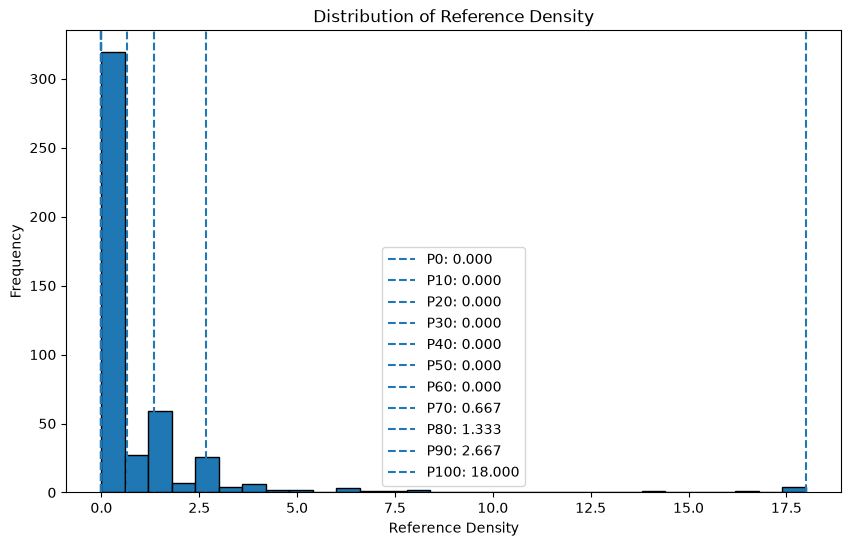

In [3]:
values = [ram_rag.ref_density(chunk[1]) for chunk in raw_chunks]
np.mean(values)
np.percentile(values,90)
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
p_values = np.percentile(values, percentiles)
import matplotlib.pyplot as plt
# Histogram
plt.figure(figsize=(10, 6))
plt.hist(values, bins=30, edgecolor="black")

# Add percentile lines
for p, value in zip(percentiles, p_values):
    plt.axvline(value, linestyle="--", label=f"P{p}: {value:.3f}")

plt.xlabel("Reference Density")
plt.ylabel("Frequency")
plt.title("Distribution of Reference Density")

plt.legend()
plt.show()

In [4]:
ref_chunks = []
for chunk in raw_chunks:
    if (ram_rag.ref_density(chunk[1])  > 20) and (ram_rag.ref_density(chunk[1])  < 30):
        ref_chunks.append(chunk[1])
ref_chunks
# above 20 looks a good number
 

[]

## The pipeline, one step at a time

`evaluate_config` (below) does this all at once. First let's run the same thing by
hand for **one** config so nothing is hidden: **chunk → embed → store**, then
**retrieve → score**. Each `ram_rag.*` call is a single-purpose function you can
inspect on its own.

In [7]:
from shared.embedder import get_embedder

# 1. chunk — strip references + drop citation-dense chunks
clean_chunks = ram_rag.remove_citation_chunks(raw_chunks)
print(f"1. chunk : {len(clean_chunks)} chunks (was {len(raw_chunks)} raw)")

# 2. embed — text → vectors
embedder = get_embedder("tei")
vectors = ram_rag.embed_chunks(embedder, clean_chunks)
print(f"2. embed : {len(vectors)} vectors, {embedder.dim}d, via {embedder.name}")



1. chunk : 465 chunks (was 465 raw)
2. embed : 465 vectors, 1024d, via tei:Qwen/Qwen3-Embedding-0.6B


In [ ]:
# 3. store — recreate the table at this dim, then COPY every row in
TABLE = ram_rag.table_name("ram", "qwen06", "fixed")   # 'tei' sirve Qwen3-Embedding
ram_rag.store_chunks(clean_chunks, vectors, embedder.dim, embedder.name, TABLE)
print(f"3. store : loaded into table '{TABLE}'")

In [ ]:
# retrieve — nearest chunks for one question against what we just stored
questions = ram_rag.load_questions()
top_hits = ram_rag.retrieve(embedder, questions[0], k=3, table=TABLE)
print("Q:", questions[0], "\n")
for source, text, distance in top_hits:
    flag = " ⚠REF" if ram_rag.is_ref_chunk(text) else ""
    print(f"  {distance:.3f} [{source}]{flag}  {text[:90]}...")

# score — same retrieval across all 20 questions, reduced to two numbers
scores = ram_rag.score_questions(embedder, questions, k=3, table=TABLE)
print(f"\nref-noise = {scores['ref_noise']:.0%}   "
      f"avg top-1 dist = {scores['avg_top1_dist']:.3f}")

## Run the three evaluation configurations

Now that the steps are clear, `evaluate_config(model, clean)` just packages them —
`ingest()` (chunk → embed → store) followed by `score_questions()` — so we can
sweep configs compactly. Each call re-ingests the corpus and evaluates all 20
questions. (bge-small embeds ~400 chunks on CPU — give it a few seconds.)

In [ ]:
baseline = ram_rag.evaluate_config("minilm", clean=False)   # baseline
baseline["config"], baseline["n_chunks"], round(baseline["avg_top1_dist"], 3), f"{baseline['ref_noise']:.0%}"

In [ ]:
references_stripped = ram_rag.evaluate_config("minilm", clean=True)    # + strip references
references_stripped["config"], references_stripped["n_chunks"], round(references_stripped["avg_top1_dist"], 3), f"{references_stripped['ref_noise']:.0%}"

In [ ]:
stronger_embedder = ram_rag.evaluate_config("bge-small", clean=True)  # + stronger embedder
stronger_embedder["config"], stronger_embedder["n_chunks"], round(stronger_embedder["avg_top1_dist"], 3), f"{stronger_embedder['ref_noise']:.0%}"

## Results

In [ ]:
import matplotlib.pyplot as plt

results = [baseline, references_stripped, stronger_embedder]
config_labels = [result["config"] for result in results]
fig, (noise_axis, count_axis) = plt.subplots(1, 2, figsize=(11, 4))

noise_axis.bar(config_labels, [result["ref_noise"] for result in results],
               color=["#cc5555", "#dd9944", "#44aa77"])
noise_axis.set_title("Reference-noise rate (lower is better)")
noise_axis.set_ylabel("fraction of retrieved chunks that are refs")
for i, result in enumerate(results):
    noise_axis.text(i, result["ref_noise"] + 0.005, f"{result['ref_noise']:.0%}", ha="center")

count_axis.bar(config_labels, [result["n_chunks"] for result in results], color="#5577bb")
count_axis.set_title("Chunks indexed (cleaning removes ref junk)")
for i, result in enumerate(results):
    count_axis.text(i, result["n_chunks"] + 3, str(result["n_chunks"]), ha="center")

for axis in (noise_axis, count_axis):
    axis.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Before / after on a question that had noise
Question 1 returned a bibliography fragment at rank 1 in the baseline. Compare
the top hit across configs:

In [ ]:
question, baseline_hits = baseline["examples"][0]
stronger_hits = stronger_embedder["examples"][0][1]
print("Q:", question, "\n")

def format_top_hit(hits):
    source, text, distance = hits[0]
    ref_flag = " ⚠REF" if ram_rag.is_ref_chunk(text) else ""
    return f"[{source}]{ref_flag}  {text[:130]}..."

print("A  minilm raw :", format_top_hit(baseline_hits))
print("C  bge +clean :", format_top_hit(stronger_hits))

## Findings (measured)

| config | #chunks | avg top-1 dist | ref-noise@3 |
|---|---|---|---|
| minilm (raw) | 653 | 0.420 | **15%** |
| minilm +clean | 392 | 0.423 | **0%** |
| bge-small +clean | 392 | **0.199** | **0%** |

- **Stripping references removed ~40% of chunks** (653 → 392) — almost all pure
  citation noise — and cut the reference-noise rate from **15% to 0%**. Cleaning
  the data, not the model, fixed the most visible failure.
- **A stronger, retrieval-tuned embedder (bge-small)** then tightened matches
  hard: avg top-1 distance **0.42 → 0.20**, and its 512-token window means no
  chunk gets truncated (MiniLM caps at 256).
- **Coverage gaps stay honest:** *Casparian strip* questions still retrieve
  weakly — no paper in this corpus covers it. RAG can't answer what isn't there.

**Where this goes next:** semantic/heading-aware chunking (Lab 03), a reranker to
push any remaining junk down (Lab 05), and a proper eval harness (Lab 06).